# Preprocessing pipeline - single-subject pilot (cohort N=163)

### Goals:
1. Confirm a valid pilot subject (present in the 163-subject cohort, with both restEC and restEO recordings)
2. Load that subject's raw EEG data into MNE and verify channel inventory/types against the BIDS `_channels.tsv`
3. Implement and validate `bipolarEOG` and `apply_filters`, matching the authors' published order and parameters
4. Implement and validate `correct_EOG` (event-locked EOG regression)
5. Implement and validate artefact detection (seven threshold-based methods)
6. Implement epoching

### Inputs:
* Filtered cohort table from Day 4 (`data/cohort_filtered_n163.xlsx`)
* Raw TDBRAIN EEG data (BDF format) and BIDS sidecar files (`_channels.tsv`, `_eeg.json`) for the pilot subject

### Assumptions:
* This is a from-scratch reimplementation in MNE-Python of the authors' published preprocessing code (`autopreprocessing.py`, Brainclinics Foundation), which does not run on the current BDF/BIDS data format — as documented in the project README. Thresholds and parameters are taken directly from the authors' code, not approximated.
* The authors' `_channels.tsv` is treated as ground truth for channel names/types (resolves a naming discrepancy between the manuscript, which lists `HOHL`, and the authors' code, which lists `HPHL`, for the same channel)
* A single pilot subject is representative enough to validate pipeline logic before scaling to all 163 - this limits the ability to catch edge cases (e.g. missing channels, unusual noise) that batch processing will eventually surface

In [1]:
# Import libraries 
import numpy as np
import pandas as pd 
from pathlib import Path    
import mne
import matplotlib.pyplot as plt
import scipy.signal                                                                                        

In [2]:
# load participants data from the filtered cohort Excel file

#define function to find repo root
def find_repo_root(marker = ".git"): # .git marks the repo root reliably regardless of who runs this or from where
    current_path = Path.cwd()
    for parent in [current_path, *current_path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory of {current_path}")

project_root = find_repo_root()
data_dir = project_root / "data" 

TDBRAIN_participant_data = pd.read_excel(data_dir/"cohort_filtered_n163.xlsx")

#confirm that the data has been loaded correctly
print(TDBRAIN_participant_data.shape)

(163, 109)


In [3]:
## Get pilot subject data

#Choose pilot subject 
pilot_subject = TDBRAIN_participant_data.iloc[0]
pilot_subject_id = pilot_subject['TDBRAIN_ID']
print(pilot_subject_id)

#Construct the path to the pilot subject's EEG data file
pilot_subject_dir = data_dir / "TDBRAIN_Dataset_V3_1" / pilot_subject_id / "ses-1" / "eeg"
pilot_restEC_file = pilot_subject_dir / f"{pilot_subject_id}_ses-1_task-restEC_eeg.bdf"

#Existence check
assert pilot_restEC_file.exists(), f"File not found: {pilot_restEC_file}"

#Load the EEG data using MNE
raw_pilot_restEC = mne.io.read_raw_bdf(pilot_restEC_file, preload=True)

#check data against the 32-channel list from _channels.tsv
print(raw_pilot_restEC.ch_names)
print(len(raw_pilot_restEC.ch_names))
print(raw_pilot_restEC.info['sfreq'])
print(raw_pilot_restEC.get_channel_types())

#fix channel types based on the _channels.tsv file
new_types = {
    'VPVA': 'eog',
    'VNVB': 'eog',
    'HPHL': 'eog',
    'HNHR': 'eog',
    'Erbs': 'ecg',
    'Mass': 'emg'
}
#apply the new channel types
raw_pilot_restEC.set_channel_types(new_types)

#re-run the checks to confirm that the channel types have been updated
print(raw_pilot_restEC.get_channel_types())

sub-87999321
Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'VPVA', 'VNVB', 'HPHL', 'HNHR', 'Erbs', 'Mass', 'Status']
33
500.0
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eog', 'eog', 'eog', 'eog', 'ecg', 'emg', 'sti

**Goal 1 & 2 summary**
1. Valid pilot subject confirmed: `sub-87999321` (present in the 163-subject cohort, both restEC/restEO available)
2. Channel count/order matched `_channels.tsv` exactly; sampling rate confirmed at 500 Hz; the `Status` channel was an expected BDF addition not present in the sidecar file, correctly auto-typed as `stim`; channel types corrected for the six non-EEG physiological channels (`VPVA`/`VNVB`/`HPHL`/`HNHR` -> `eog`, `Erbs` -> `ecg`, `Mass` -> `emg`).

In [4]:
##Implement and validate `bipolarEOG` and `apply_filters`, matching the authors' published order and parameters

#Extract the four raw channels' data for the bipolar EOG calculation
eog_data = raw_pilot_restEC.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])

#check the shape of the extracted data
print(eog_data.shape)  # Should be (4, n_samples)

#Compute the two derived signals 
VEOG = eog_data[0, :] - eog_data[1, :]  # Vertical EOG
HEOG = eog_data[2, :] - eog_data[3, :]  # Horizontal EOG

#Combine the derived signals into a single array
bipolar_eog_data = np.vstack((VEOG, HEOG))

#Build an Info object describing these two new channels
info = mne.create_info(ch_names=['VEOG', 'HEOG'], sfreq=raw_pilot_restEC.info['sfreq'], ch_types=['eog', 'eog'])

#Construct the RawArray from the stacked data and this Info
bipolar_eog = mne.io.RawArray(bipolar_eog_data, info)

#Merge it into the original Raw object
raw_pilot_restEC.add_channels([bipolar_eog], force_update_info=True)

(4, 60500)
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.


<RawBDF | sub-87999321_ses-1_task-restEC_eeg.bdf, 35 x 60500 (121.0 s), ~16.2 MiB, data loaded>

In [5]:
#Re-run the checks to confirm that the new channels have been added
print(raw_pilot_restEC.ch_names)   

#spot check the new channels' data  
eog_data_orig = raw_pilot_restEC.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])
eog_data_bipolar = raw_pilot_restEC.get_data(picks=['VEOG', 'HEOG'])

sample_indices = [0, 30000, 60499]  # first, middle, last

for i in sample_indices:
    veog_expected = eog_data_orig[0, i] - eog_data_orig[1, i]  # VPVA - VNVB
    veog_actual = eog_data_bipolar[0, i]
    heog_expected = eog_data_orig[2, i] - eog_data_orig[3, i]  # HPHL - HNHR
    heog_actual = eog_data_bipolar[1, i]
    print(i, "VEOG match:", np.isclose(veog_expected, veog_actual), "| HEOG match:", np.isclose(heog_expected, heog_actual))


['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'VPVA', 'VNVB', 'HPHL', 'HNHR', 'Erbs', 'Mass', 'Status', 'VEOG', 'HEOG']
0 VEOG match: True | HEOG match: True
30000 VEOG match: True | HEOG match: True
60499 VEOG match: True | HEOG match: True


In [6]:
#Drop VPVA/VNVB/HPHL/HNHR
raw_pilot_restEC.drop_channels(['VPVA', 'VNVB', 'HPHL', 'HNHR'])
print(raw_pilot_restEC.ch_names)
print(len(raw_pilot_restEC.ch_names))

['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'Erbs', 'Mass', 'Status', 'VEOG', 'HEOG']
31


**`bipolarEOG` summary**

Computed `VEOG = VPVA - VNVB` and `HEOG = HPHL - HNHR` from the four raw EOG electrodes, matching the authors' `bipolarEOG` formula. Spot-checked the derived channels against the raw channels at three sample points (first, middle, last) using `np.isclose()` - all matched exactly. The original four raw EOG channels (`VPVA`/`VNVB`/`HPHL`/`HNHR`) were then dropped to match the authors' pipeline, which replaces rather than retains them. Final channel count: 31 (26 EEG, `Erbs`, `Mass`, `Status`, `VEOG`, `HEOG`).

In [7]:
#Apply the filters in the order specified by the authors

#save original data for later comparison 
original_data = raw_pilot_restEC.copy()
#create a function to apply the filters in the specified order
def apply_filters(data, Fs, hpfreq, lpfreq, notchfreq, Q):
    # data: a single channel's 1D array, provided by MNE when this function 
    # is called via raw.apply_function() 
    b_notch, a_notch = scipy.signal.iirnotch(w0=notchfreq, Q=Q, fs=Fs)
    b_high, a_high = scipy.signal.butter(N=4, Wn=hpfreq/(Fs/2), btype='highpass')
    b_low, a_low = scipy.signal.butter(N=4, Wn=lpfreq/(Fs/2), btype='lowpass')

    data = scipy.signal.filtfilt(b_notch, a_notch, data)
    data = scipy.signal.filtfilt(b_high, a_high, data)
    data = scipy.signal.filtfilt(b_low, a_low, data)
    return data
#Apply the filters to the raw data using the specified parameters
raw_pilot_restEC.apply_function(
    apply_filters,
    picks= mne.pick_types(raw_pilot_restEC.info, eeg=True, eog=True, ecg=True, emg=True, stim=False), #Exclude the statues (stim) channels from filtering  
    channel_wise=True, #call function once per channel
    Fs=raw_pilot_restEC.info['sfreq'],
    hpfreq=0.5,
    lpfreq=100,
    notchfreq=50,
    Q=100
)

<RawBDF | sub-87999321_ses-1_task-restEC_eeg.bdf, 31 x 60500 (121.0 s), ~14.3 MiB, data loaded>

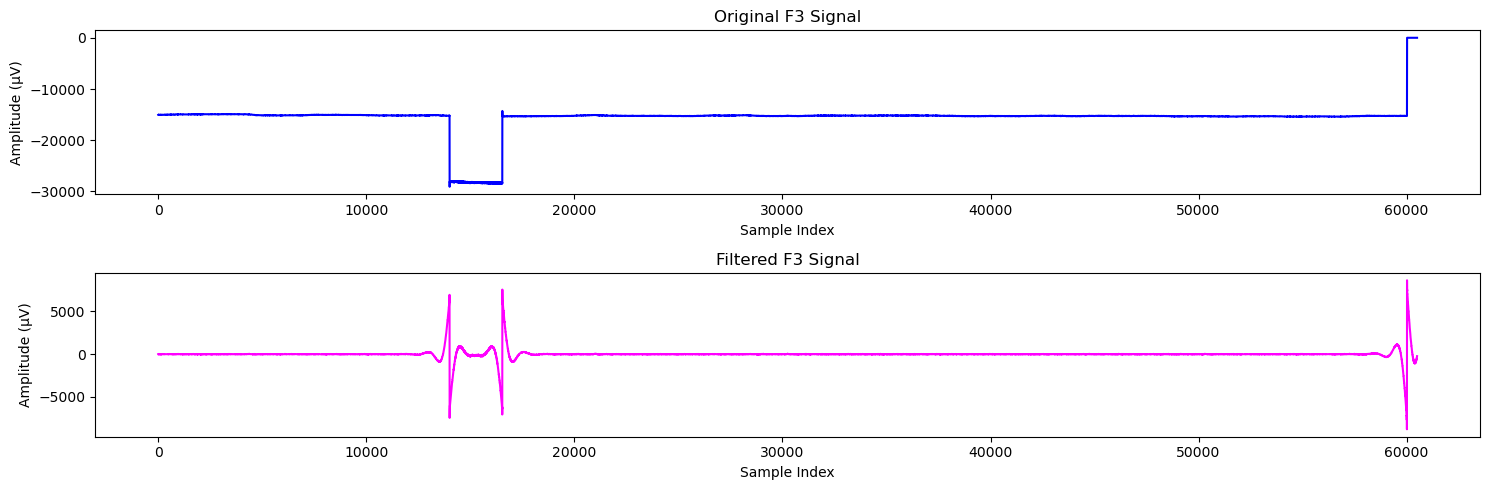

In [8]:
#Visual confirmation of the filtering effect on a sample EEG channel
channel_name = 'F3'  # Choose a channel to visualize
#Extract the original and filtered data for this channel
original_data_F3 = original_data.get_data(picks=[channel_name])[0] * 1e6
filtered_data_F3 = raw_pilot_restEC.get_data(picks=[channel_name])[0] * 1e6
#Plot the original and filtered signals for comparison
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(original_data_F3, color='blue', label='Original F3')
plt.title('Original F3 Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_data_F3, color='magenta', label='Filtered F3')
plt.title('Filtered F3 Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

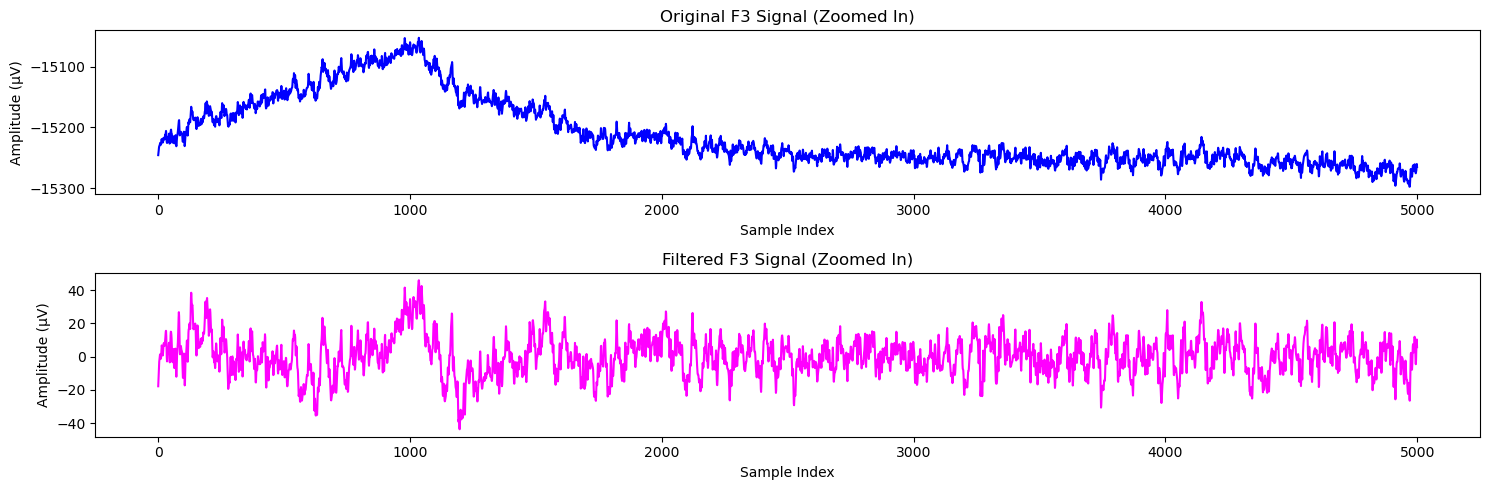

In [ ]:
#zooming into a short, artefact-free stretch to visualize the filtering effect more clearly
start_sample = 20000
end_sample = 25000
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(original_data_F3[start_sample:end_sample], color='blue', label='Original F3')
plt.title('Original F3 Signal (Zoomed In)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_data_F3[start_sample:end_sample], color='magenta', label='Filtered F3')
plt.title('Filtered F3 Signal (Zoomed In)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

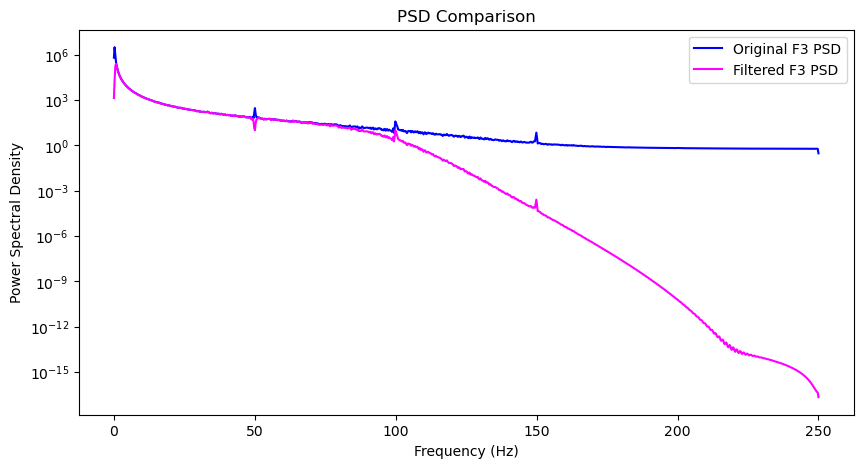

In [10]:
#validate the notch filter by checking the power spectral density (PSD) before and after filtering
#Compute the PSD of the original and filtered signals for the chosen channel
freqs_original, psd_original = scipy.signal.welch(original_data_F3, fs=raw_pilot_restEC.info['sfreq'], nperseg=2048)
freqs_filtered, psd_filtered = scipy.signal.welch(filtered_data_F3, fs=raw_pilot_restEC.info['sfreq'], nperseg=2048)

plt.figure(figsize=(10, 5))
plt.semilogy(freqs_original, psd_original, color='blue', label='Original F3 PSD')
plt.semilogy(freqs_filtered, psd_filtered, color='magenta', label='Filtered F3 PSD')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison')
plt.legend()
plt.show()


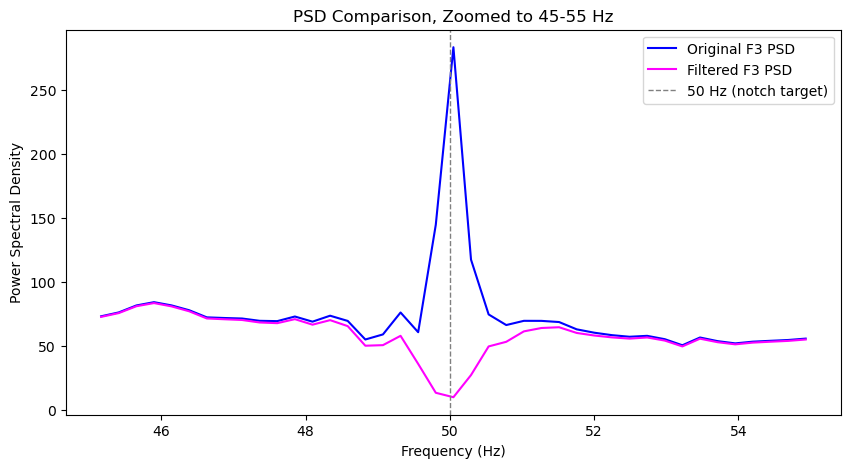

In [11]:
# Zoom into a narrow window around 50 Hz to check for the notch filter's effect directly.
# The notch filter (Q=100, notchfreq=50) has a bandwidth of ~50/100 = 0.5 Hz, so a broad
# 0-250 Hz view isn't fine-grained enough to see it clearly - this narrows the x-axis
# to 45-55 Hz specifically, where a working notch should show up as a sharp local dip.

freq_mask = (freqs_original >= 45) & (freqs_original <= 55)  # boolean mask for the frequency range of interest

plt.figure(figsize=(10, 5))
plt.plot(freqs_original[freq_mask], psd_original[freq_mask], color='blue', label='Original F3 PSD')
plt.plot(freqs_filtered[freq_mask], psd_filtered[freq_mask], color='magenta', label='Filtered F3 PSD')
# linear y-axis here, not semilogy — over this narrow a range, a linear scale makes
# a local dip easier to read than a log scale would
plt.axvline(50, color='gray', linestyle='--', linewidth=1, label='50 Hz (notch target)')  # reference line at the exact target frequency
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison, Zoomed to 45-55 Hz')
plt.legend()
plt.show()

**`apply_filters` validation summary**

Time-domain check on channel F3 confirmed the highpass filter removed the large DC offset (~-15 to −28 mV raw) and slow drift, leaving oscillatory signal in a physiologically plausible +-20–40 µV range. PSD comparison confirmed the lowpass filter suppressed power above ~100 Hz relative to the unfiltered signal. A zoomed PSD (45-55 Hz) confirmed the notch filter specifically suppresses the 50 Hz mains peak (~280 -> ~5 PSD units), with the dip localized to roughly 49-51 Hz, consistent with the `Q=100` setting. The 100 Hz and 150 Hz mains harmonics remain largely unfiltered, as expected as the authors' notch filter only targets 50 Hz, not its harmonics.

**Open item for artefact detection**

Three step-like discontinuities were visually identified in channel F3's raw signal during filter validation (two around samples ~14,000–16,500, one near the recording's end, ~sample 60,000). These produced sharp transient spikes in the filtered signal (an expected highpass response to a step discontinuity, not a filtering bug). Plausibly the kind of artefact the authors' `detect_jumps` method is designed to catch - not addressed in this notebook, flagged here so it isn't lost before artefact detection is implemented.

**Session status**

Goals 1–3 complete and validated on pilot subject `sub-87999321`:
1. Pilot subject confirmed (cohort member, both restEC/restEO available)
2. Channel inventory loaded and verified against `_channels.tsv`; types corrected
3. `bipolarEOG` and `apply_filters` implemented, matching the authors' published order and parameters; both validated (spot-check for bipolarEOG, time-domain + PSD checks for apply_filters)

Not yet started: goal 4 (`correct_EOG`), goal 5 (artefact detection), goal 6 (epoching).